In [13]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.callbacks import TensorBoard
from sklearn.utils import class_weight
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report
import os
import datetime
import json
import joblib

In [14]:
os.makedirs("results", exist_ok=True)
os.makedirs("logs/fit/Dense/", exist_ok=True)

log_dir = "logs/fit/Dense/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback = TensorBoard(log_dir=log_dir, histogram_freq=1)

In [15]:
df = pd.read_csv("../day_approach_maskedID_timeseries.csv")  
df = df.drop(columns=["Athlete ID", "Date"])
df.fillna(df.median(), inplace=True)

In [16]:
X = df.drop(columns=["injury"])
y = df["injury"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


In [17]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [18]:
y_train = np.array(y_train)
y_test = np.array(y_test)

In [19]:
class_weights = class_weight.compute_class_weight("balanced", classes=np.unique(y_train), y=y_train)
class_weight_dict = {i: class_weights[i] for i in range(len(class_weights))}

In [20]:
X_train.shape[1]

70

In [21]:
model = keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)), 
    layers.Dense(128, activation="relu"),  
    layers.Dropout(0.3),  
    layers.Dense(64, activation="relu"), 
    layers.Dropout(0.3),
    layers.Dense(32, activation="relu"),  
    layers.Dense(1, activation="sigmoid")  
])

model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

In [22]:
history = model.fit(
    X_train, y_train, 
    epochs=50, 
    batch_size=32, 
    validation_data=(X_test, y_test), 
    class_weight=class_weight_dict,
    callbacks=[tensorboard_callback],  
    verbose=1
)

model.save("results/Dense/injury_prediction_model.h5")

Epoch 1/50
1070/1070 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6616 - loss: 0.8022 - val_accuracy: 0.5589 - val_loss: 0.6529
Epoch 2/50
1070/1070 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.5860 - loss: 0.6438 - val_accuracy: 0.4403 - val_loss: 0.7121
Epoch 3/50
1070/1070 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.5182 - loss: 0.6532 - val_accuracy: 0.7017 - val_loss: 0.5631
Epoch 4/50
1070/1070 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6477 - loss: 0.6258 - val_accuracy: 0.4116 - val_loss: 0.7486
Epoch 5/50
1070/1070 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.5840 - loss: 0.6219 - val_accuracy: 0.4433 - val_loss: 0.7218
Epoch 6/50
1070/1070 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.5453 - loss: 0.6476 - val_accuracy: 0.6882 - val_loss: 0.5747
Epoch 7/50
1070/1070 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.5934 - loss: 0.6195 - val_accuracy: 0.6223 - val_loss: 0.6564
Epoch 8/50
1070/1070 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6318 - loss: 0.6099 - 

In [23]:
with open("results/Dense/training_history.json", "w") as f:
    json.dump(history.history, f)

joblib.dump(scaler, "results/Dense/scaler.pkl")

with open("results/Dense/class_weights.json", "w") as f:
    json.dump(class_weight_dict, f)

y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("AUC-ROC:", roc_auc_score(y_test, y_pred_prob))
print("Classification Report:\n", classification_report(y_test, y_pred))

class CustomTensorBoardCallback(TensorBoard):
    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        logs["roc_auc"] = roc_auc_score(y_test, self.model.predict(X_test))
        super().on_epoch_end(epoch, logs)

custom_tensorboard_callback = CustomTensorBoardCallback(log_dir=log_dir, histogram_freq=1)


268/268 ━━━━━━━━━━━━━━━━━━━━ 0s 640us/step
Accuracy: 0.9249473930324994
AUC-ROC: 0.5480595747870846
Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.94      0.96      8437
           1       0.03      0.14      0.05       117

    accuracy                           0.92      8554
   macro avg       0.51      0.54      0.50      8554
weighted avg       0.97      0.92      0.95      8554



In [24]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

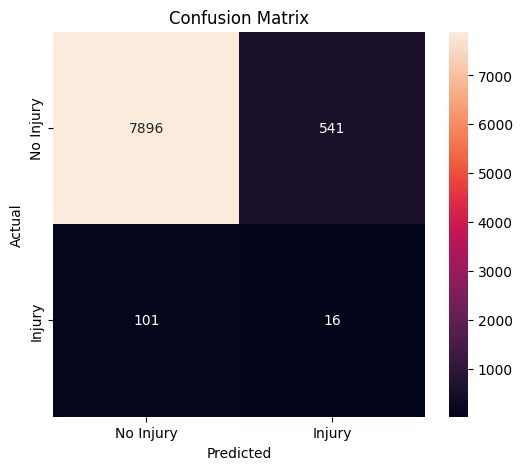

In [25]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=["No Injury", "Injury"], yticklabels=["No Injury", "Injury"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()